##Emotion Classification with RNNs, LSTMs & GRUs
Classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an Advanced Bidirectional GRU.

##1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

##2. Load Dataset
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [25]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

In [26]:
label_names=emotion_dataset['train'].features['label'].names

In [27]:
df_train=pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)
df_test=pd.DataFrame(
    {
        'text':test_text,
        'label':[label_names[i] for i in test_label]
    }
)

In [28]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [29]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [30]:
df_train.isnull().sum()

,0
text,0
label,0


##3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels

In [31]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

Basically we are checking if we have multiclass classification problem. And by looking at the countplot we can see that there is multiclass classification problem and for resolving it we will use class weight as it focus on minority classes.

<Axes: xlabel='label', ylabel='count'>

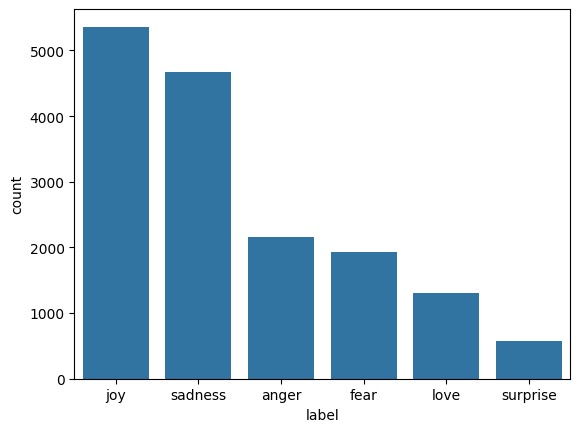

In [32]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

##4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

Basically we are tokenizing the text and we are doing it to only 10000 words and in case if any words come to which is new for our model will also get tokenize by using 'oov_token'.
Also we are not using one-hot encoding because it will produce large number of columns as we have 16000 rows of text.
And also label encoding will produce many number for each characters due to which oue model will not understand which words are imp.

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words=10000


tokenizer= Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences=tokenizer.texts_to_sequences(df_train['text'])
test_sequences=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences=pad_sequences(train_sequences, maxlen=50, padding='post', truncating='post')
padded_test_sequences=pad_sequences(test_sequences, maxlen=50, padding='post', truncating='post')

train_label=np.array(train_label)
test_label=np.array(test_label)

num_classes=len(np.unique(train_label))

print(f"Vocabulary size:{len(tokenizer.word_index)}")
print(f"Max Sentance Length:{padded_train_sequences.shape[1]}")


Vocabulary size:15213
Max Sentance Length:50


##5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [34]:
from sklearn.utils import class_weight

class_weight= class_weight.compute_class_weight(
    class_weight='balanced',
    classes= np.unique(train_label),
    y= train_label

)

class_weight_dict=dict(enumerate(class_weight))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping= EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

##6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

##6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model=Sequential([
    Embedding(input_dim= max_words, output_dim= 128, input_length= 50),
    SimpleRNN(units= 128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units= 64),
    Dropout(0.5),
    Dense(units= num_classes, activation= 'softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [37]:
rnn_model.fit(
    padded_train_sequences,
    train_label,
    epochs=20,
    validation_data=(padded_test_sequences, test_label),
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    batch_size=32
)

rnn_loss, rnn_accuracy= rnn_model.evaluate(padded_test_sequences, test_label)

print(f"rnn loss:{rnn_loss}")
print(f"rnn accuracy:{rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.1644 - loss: 1.9023 - val_accuracy: 0.1085 - val_loss: 1.8232
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1628 - loss: 1.8076 - val_accuracy: 0.1135 - val_loss: 1.8087
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.1577 - loss: 1.7848 - val_accuracy: 0.2305 - val_loss: 1.7749
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.1622 - loss: 1.7773 - val_accuracy: 0.2125 - val_loss: 1.7713
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.1634 - loss: 1.7650 - val_accuracy: 0.1120 - val_loss: 1.7928
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.1489 - loss: 1.7610 - val_accuracy: 0.1010 - val_loss: 1.8102
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.1516 - loss: 1.7391 - val_accuracy: 0.1290 - val_loss: 1.7896
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2125 - loss: 1.7713
rnn loss:1.77133

##6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [38]:
lstm_model=Sequential([
    Embedding(input_dim= max_words, output_dim= 128, input_length= 50),
    LSTM(units= 128, return_sequences=True),
    Dropout(0.5),
    LSTM(units= 64),
    Dropout(0.5),
    Dense(units= num_classes, activation= 'softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
lstm_model.fit(
    padded_train_sequences,
    train_label,
    epochs=20,
    validation_data=(padded_test_sequences, test_label),
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    batch_size=32
)

lstm_loss, lstm_accuracy= lstm_model.evaluate(padded_test_sequences, test_label)

print(f"LSTM loss:{lstm_loss}")
print(f"LSTM accuracy:{lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 126ms/step - accuracy: 0.1490 - loss: 1.7954 - val_accuracy: 0.0330 - val_loss: 1.8049
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 117ms/step - accuracy: 0.1378 - loss: 1.7942 - val_accuracy: 0.1450 - val_loss: 1.7856
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 127ms/step - accuracy: 0.1577 - loss: 1.7932 - val_accuracy: 0.1370 - val_loss: 1.8031
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.0330 - loss: 1.8049
LSTM loss:1.8049205541610718
LSTM accuracy:0.032999999821186066


##6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [40]:
gru_model=Sequential([
    Embedding(input_dim= max_words, output_dim= 128, input_length= 50),
    GRU(units= 128, return_sequences=True),
    Dropout(0.5),
    GRU(units= 64),
    Dropout(0.5),
    Dense(units= num_classes, activation= 'softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
gru_model.fit(
    padded_train_sequences,
    train_label,
    epochs=20,
    validation_data=(padded_test_sequences, test_label),
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    batch_size=32
)

gru_loss, gru_accuracy= gru_model.evaluate(padded_test_sequences, test_label)

print(f"GRU loss:{gru_loss}")
print(f"GRU accuracy:{gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 105ms/step - accuracy: 0.1443 - loss: 1.7962 - val_accuracy: 0.0795 - val_loss: 1.8110
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 103ms/step - accuracy: 0.1496 - loss: 1.7947 - val_accuracy: 0.1135 - val_loss: 1.8072
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 105ms/step - accuracy: 0.1388 - loss: 1.7941 - val_accuracy: 0.2870 - val_loss: 1.7820
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.0795 - loss: 1.8110
GRU loss:1.8109596967697144
GRU accuracy:0.0794999971985817


##6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [42]:
result_df= pd.DataFrame({
    'Model': ['RNN','LSTM','GRU'],
    'Test Loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy, lstm_accuracy, gru_accuracy]
})

result_df.sort_values(by='Test Accuracy', ascending=False)

,Model,Test Loss,Test Accuracy
0,RNN,1.771335,0.2125
2,GRU,1.810960,0.0795
1,LSTM,1.804921,0.0330


#7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

##7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [43]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train & Evaluate Advanced Bidirectional GRU


In [44]:
BiGRU.fit(
    padded_train_sequences,
    train_label,
    validation_data=(padded_test_sequences, test_label),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 155s 298ms/step - accuracy: 0.6114 - loss: 0.9908 - val_accuracy: 0.8945 - val_loss: 0.3150
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 295ms/step - accuracy: 0.9218 - loss: 0.2332 - val_accuracy: 0.9185 - val_loss: 0.2167
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 302ms/step - accuracy: 0.9471 - loss: 0.1486 - val_accuracy: 0.9155 - val_loss: 0.2400
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 300ms/step - accuracy: 0.9600 - loss: 0.1117 - val_accuracy: 0.9155 - val_loss: 0.2334
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 295ms/step - accuracy: 0.9679 - loss: 0.0912 - val_accuracy: 0.9135 - val_loss: 0.2857


In [45]:
BiGRU_loss, BiGRU_accuracy= BiGRU.evaluate(padded_test_sequences, test_label)

print(f"GRU loss:{BiGRU_loss}")
print(f"GRU accuracy:{BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9185 - loss: 0.2167
GRU loss:0.21668492257595062
GRU accuracy:0.9185000061988831


#8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

##8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step


<Axes: >

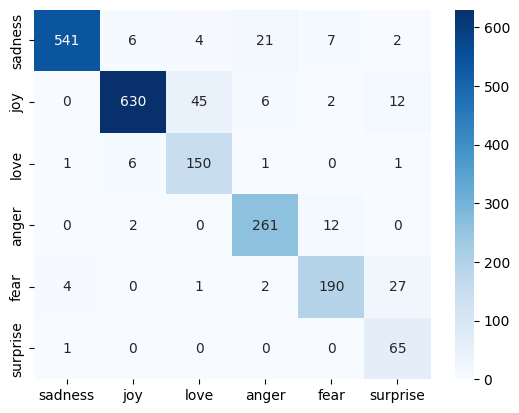

In [46]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)



#9. Final Predictions
Test the winning model on unseen sample sentences.

In [47]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences= pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions= np.argmax(BiGRU.predict(sample_padded_sequences), axis= 1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: anger
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


#10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [48]:
import os
import pickle

make_dir='Artifacts'
os.makedirs(make_dir, exist_ok= True)

# Saving our BiGRU model
BiGRU.save(os.path.join(make_dir, 'BiGRU_Model.keras'))

# Save tokenizer
with open(os.path.join(make_dir, 'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer, file)